<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_3_MLR_Ames_Part3_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 3
## Regularization
Author: Brad Sheese

To recap:

- Exercise 1: Focused on data cleaning and feature reduction for the Ames Dataset.

- Exercise 2: Applied forward and backward feature selection incorporating both linear and non-linear (polynomial) features. Showed issues with multicollinearity.

This notebook:

- Introduces regularization techniques, specifically Lasso, Ridge, and Elastic Net, to help prevent overfitting and improve model generalization.


Data Source:
-  http://jse.amstat.org/v19n3/decock/AmesHousing.txt

## Preliminaries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

# Load and clean the Ames dataset (with one-hot encoding for regularization)
df = load_and_clean_ames(one_hot_encode=True)
print(f"DataFrame shape: {df.shape}")


DataFrame shape: (2925, 39)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MS SubClass            2925 non-null   int64  
 1   Lot Frontage           2925 non-null   float64
 2   Lot Area               2925 non-null   int64  
 3   Overall Qual           2925 non-null   int64  
 4   Overall Cond           2925 non-null   int64  
 5   Year Built             2925 non-null   int64  
 6   Year Remod/Add         2925 non-null   int64  
 7   BsmtFin SF 1           2925 non-null   float64
 8   BsmtFin SF 2           2925 non-null   boolean
 9   Bsmt Unf SF            2925 non-null   float64
 10  Total Bsmt SF          2925 non-null   float64
 11  1st Flr SF             2925 non-null   int64  
 12  2nd Flr SF             2925 non-null   int64  
 13  Gr Liv Area            2925 non-null   int64  
 14  Bsmt Full Bath         2925 non-null   float64
 15  Full Bath

### Feature Selection and Evaluation Function

In [8]:
from typing import Dict, Any, Optional
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def perform_feature_selection_and_evaluation(
    X: pd.DataFrame,
    y: pd.Series,
    model_type: str = 'ols',
    alpha: float = 1.0,
    l1_ratio: float = 0.5,
    selection_direction: str = 'forward',
    cv_folds: int = 5
) -> Dict[str, Any]:
    """
    Performs feature selection and evaluates a regression model using cross-validation.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        model_type (str): 'ols', 'lasso', 'ridge', or 'elasticnet'.
        alpha (float): Regularization strength for Lasso, Ridge, and ElasticNet.
                       Higher values = stronger penalty. (Ignored for 'ols').
        l1_ratio (float): The ElasticNet mixing parameter (0.0 to 1.0).
                          0 = Ridge, 1 = Lasso. (Ignored for other models).
        selection_direction (str): 'forward' or 'backward' for OLS SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing the fitted pipeline, selected feature names, and CV metrics.
    """
    model_type = model_type.lower()

    # 1. Build a Pipeline based on the requested model type
    if model_type == 'ols':
        # OLS requires a separate step to handle feature selection
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('selector', SequentialFeatureSelector(
                LinearRegression(),
                n_features_to_select='auto',
                direction=selection_direction,
                cv=cv_folds
            )),
            ('model', LinearRegression())
        ]
    elif model_type == 'lasso':
        # Lasso handles feature selection internally via the L1 penalty
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha, random_state=42))
        ]
    elif model_type == 'ridge':
        # Ridge penalizes large coefficients but keeps all features (L2 penalty)
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha, random_state=42, max_iter=10000))
        ]
    elif model_type == 'elasticnet':
        # ElasticNet combines both L1 and L2 penalties
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
        ]
    else:
        raise ValueError("model_type must be 'ols', 'lasso', 'ridge', or 'elasticnet'")

    pipeline = Pipeline(pipeline_steps)

    # 2. Perform Cross-Validation
    scoring_metrics =['r2', 'neg_mean_squared_error']
    cv_results = cross_validate(pipeline, X, y, cv=cv_folds, scoring=scoring_metrics)

    cv_r2 = cv_results['test_r2']
    cv_mse = -cv_results['test_neg_mean_squared_error'] # Negating to make it positive

    print(f"--- Model Evaluation ({model_type.upper()}) ---")
    print(f"Cross-validated R-squared: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"Cross-validated MSE:       {cv_mse.mean():.4f} ± {cv_mse.std():.4f}\n")

    # 3. Fit the pipeline on the ENTIRE dataset to get final features and coefficients
    # again, ENTIRE is this case typically means either the entire train or testset
    pipeline.fit(X, y)
    final_model = pipeline.named_steps['model']

    # 4. Extract features and formatted outputs based on the algorithm
    print(f"Intercept: {final_model.intercept_:.4f}\n")

    if model_type == 'ols':
        print(f"Standardized Coefficients (using {selection_direction} selection):")
        final_selector = pipeline.named_steps['selector']  # Extracts the trained feature selector from the pipeline.
        selected_mask = final_selector.get_support() # Ask the trained feature selector for the selections

        # OLS drops features completely from the array
        selected_feature_names = X.columns[selected_mask].tolist()
        display_names = selected_feature_names
        display_coefs = final_model.coef_

    else:
        # Regularized models process all features, but shrink some to exactly 0.0
        # For display, want to show all features so students can see the 0.0s
        param_str = f"alpha={alpha}" + (f", l1_ratio={l1_ratio}" if model_type == 'elasticnet' else "")
        print(f"Standardized Coefficients (using {model_type.capitalize()} Regularization | {param_str}):")

        display_names = X.columns.tolist()
        display_coefs = final_model.coef_

        # Determine which features survived the penalty (non-zero coefficients)
        # Using np.isclose to handle tiny floating point inaccuracies
        selected_feature_names =[
            name for name, coef in zip(display_names, display_coefs) if not np.isclose(coef, 0.0)
        ]

    # Print the coefficients neatly
    if display_names:
        max_feature_len = max(len(feature) for feature in display_names)
        for name, coef in zip(display_names, display_coefs):
            # Highlight features that were completely dropped by Lasso/ElasticNet
            if np.isclose(coef, 0.0):
                print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}  <-- Dropped")
            else:
                print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}")
    else:
        print("\tNo features selected.")

    print(f"\nTotal Features Kept: {len(selected_feature_names)} out of {len(X.columns)}")

    # 5. Return the metrics
    return {
        'model_pipeline': pipeline,
        'selected_features': selected_feature_names,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mse_mean': cv_mse.mean(),
        'cv_mse_std': cv_mse.std()
    }

### Model Work-Flow Function

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

def run_modeling_workflow(
    X: pd.DataFrame,
    y: pd.Series,
    model_type: str = 'ols',
    alpha: float = 1.0,
    l1_ratio: float = 0.5,
    test_size: float = 0.20,
    random_state: int = 42,
    selection_direction: str = 'forward',
    cv_folds: int = 5,
    plot_residuals: bool = True
) -> Dict[str, Any]:
    """
    Encapsulates the entire MLR modeling workflow including train-test split,
    feature selection/regularization, model training, evaluation, and residual plotting.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        model_type (str): 'ols', 'lasso', 'ridge', or 'elasticnet'.
        alpha (float): Regularization strength for Lasso, Ridge, and ElasticNet.
        l1_ratio (float): The ElasticNet mixing parameter (0.0 to 1.0).
        test_size (float): The proportion of the dataset to include in the test split.
        random_state (int): Seed used by the random number generator for reproducibility.
        selection_direction (str): 'forward' or 'backward' for OLS SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.
        plot_residuals (bool): Whether to plot residuals.

    Returns:
        dict: A dictionary containing final test metrics, selected features,
              the fitted pipeline, residuals, and test predictions.
    """

    # 1. TRAIN-TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 2. CROSS-VALIDATION & FEATURE SELECTION/REGULARIZATION
    print(f"--- Running {model_type.upper()} Cross-Validation on Training Data ---")
    results = perform_feature_selection_and_evaluation(
        X=X_train,
        y=y_train,
        model_type=model_type,
        alpha=alpha,
        l1_ratio=l1_ratio,
        selection_direction=selection_direction,
        cv_folds=cv_folds
    )

    final_model = results['model_pipeline']
    selected_features = results['selected_features']

    # 3. FINAL EVALUATION ON UNSEEN TEST DATA
    print("\n--- Running Final Evaluation on Unseen Test Data ---")
    test_predictions = final_model.predict(X_test)

    final_r2 = r2_score(y_test, test_predictions)
    final_mse = mean_squared_error(y_test, test_predictions)

    print(f"Final Test R-squared: {final_r2:.4f}")
    print(f"Final Test MSE:       {final_mse:.4f}")

    # 4. RESIDUAL ANALYSIS
    residuals = y_test - test_predictions

    if plot_residuals:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(residuals, kde=True)
        plt.title('Histogram of Residuals')
        plt.xlabel('Residual Value')
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        sns.scatterplot(x=test_predictions, y=residuals)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.title('Residuals vs. Predicted Values')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')

        plt.tight_layout()
        plt.show()

    return {
        'final_r2': final_r2,
        'final_mse': final_mse,
        'selected_features': selected_features,
        'model_pipeline': final_model,
        'residuals': residuals,
        'test_predictions': test_predictions,
        'cv_r2_mean': results['cv_r2_mean'],
        'cv_r2_std': results['cv_r2_std'],
        'cv_mse_mean': results['cv_mse_mean'],
        'cv_mse_std': results['cv_mse_std']
    }

### Define X and y

In [10]:
X = df.drop(columns=['SalePrice'])

# Log-transform the target to handle right-skew (see Part 2)
y = df['SalePrice'].map(np.log)

### Feature Selection the Old-School Way with OLS (for comparison)
We've done this in previous exercises, but let's run this again here so we can compare the results.

--- Running OLS Cross-Validation on Training Data ---
--- Model Evaluation (OLS) ---
Cross-validated R-squared: 0.8895 ± 0.0172
Cross-validated MSE:       0.0181 ± 0.0042

Intercept: 12.0180

Standardized Coefficients (using forward selection):
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.08
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.02
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	Gr Liv Area          :	    0.13
	Bsmt Full Bath       :	    0.01
	Fireplaces           :	    0.02
	Garage Cars          :	    0.02
	Garage Area          :	    0.02
	Yr Sold              :	   -0.01
	MS Zoning_RL         :	    0.02
	Lot Shape_Reg        :	   -0.01
	Bldg Type_1Fam       :	    0.02
	Sale Condition_Normal:	    0.01
	Foundation_PConc     :	    0.02

Total Features Kept: 19 out of 38

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.9337
Final Test

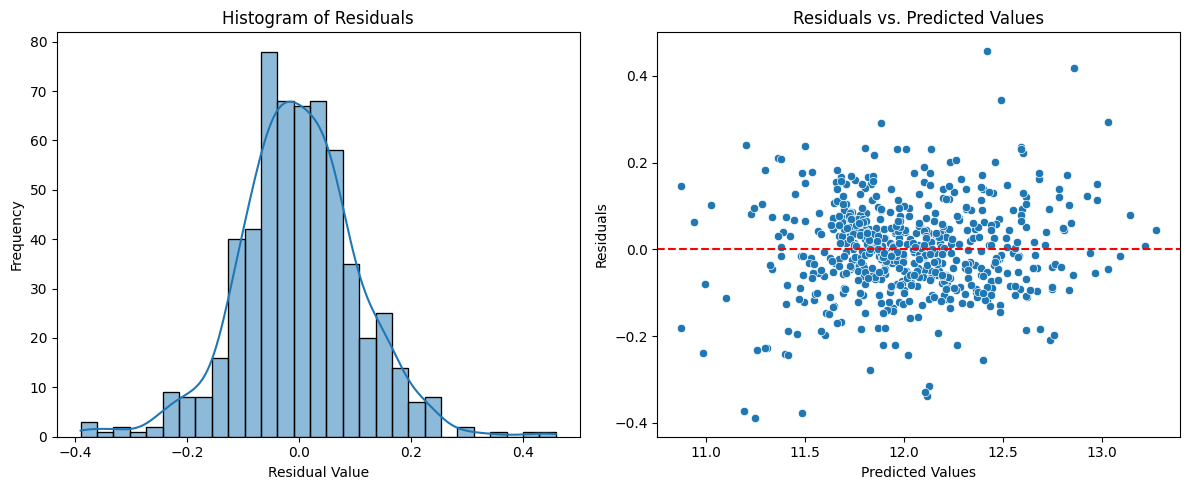

In [11]:
# 1. Classic OLS with Forward Selection
ols_results = run_modeling_workflow(X, y, model_type='ols', selection_direction='forward')

## Regularization

In machine learning, regularization is a technique that penalizes a model for being too complex. We are introducing regularization in the context of regression but we will see it applied in other contexts as well later in the course.

By default, a regression model wants to minimize its error on the training data, but it will happily assign massive weights in pursuit of the best fit. The problem with massive weights is that they make the model highly unstable—even a tiny change in an input will cause a massive swing in the prediction. This causes the model to memorize random noise rather than true patterns. Regularization introduces a mathematical penalty for large coefficients. It forces the model to compromise: it must balance finding the lowest error while also keeping the feature weights as small and simple as possible. Think of it as putting a budget on your model's coefficients so it doesn't overcomplicate things and fail on new data.

In our previous exercise, we used Forward and Backward Selection to reduce our features and simplify our models. We wanted to make models that were interpretable and potentionally actionable for the human audience. While stepwise selection is an intuitive way to achieve this, regularization is widely considered a much more modern and powerful approach. Here is why:

1. Forward and backward selection are binary and harsh. A feature is either 100% in the model or 100% out. Regularization is much more nuanced. If a feature is only slightly helpful, regularization doesn't have to throw it away completely; it can just shrink its coefficient down to a very small number. It turns down the volume on noisy features instead of abruptly muting them.

2. Regularized models are much more stable. Stepwise selection is notoriously unstable. Because it relies on a rigid step-by-step process, changing just a few rows of your training data can cause the algorithm to choose a completely different set of features. Regularization evaluates all the features at once, resulting in a much smoother, more robust model that doesn't drastically change when exposed to new data.

3. Regularization is much better at handling multicollinearity. If you have two highly correlated features (like "Garage Area" and "Garage Capacity"), stepwise selection gets easily confused; it will pick one based on a tiny mathematical margin and dump the other. Regularization is desgined to handle with more gracefully. For example, Ridge keeps both but shrinks their weights so they share the predictive power.

4. Regularization is computationally faster. Forward and backward selection are incredibly slow because the computer has to train and compare hundreds or thousands of different models, adding or removing one feature at a time. Regularization is mathematically elegant; it trains one model while simultaneously applying the penalty, making it significantly faster, especially when dealing with a large number of features. For example, the first time I ran forward selection on the full Ames model with cross-validation the analysis took 90 minutes to complete. The same analysis using modern regularization methods yielded nearly identical results and finished in seconds.

### Ridge Regression (L2 Regularization)

*Historical note: Ridge regression was developed in the 1970's and has its roots in Soviet mathematics from the 1940's. Optional reading that covers both the history and mathematics: https://en.wikipedia.org/wiki/Ridge_regression*

In a standard Ordinary Least Squares (OLS) regression, having overlapping variables—like `Total Bsmt SF` and `Finished Bsmt SF`causes the math to become highly unstable. The model cannot figure out which variable deserves the "credit" for the prediction, causing the coefficients to swing wildly. A slight change in the training data might cause a coefficient to flip from +50,000 to -50,000. Ridge regression solves this instability by stepping in and constraining the coefficients, trading a little bit of bias for a massive increase in reliability.

Ridge regression modifies the standard OLS math by adding a penalty for model complexity. Think of the penality as like a tax that discourages large coefficients. Ridge uses an L2 Penalty, which calculates the tax based on the squared value of the coefficients. Because the penalty is squared, Ridge heavily punishes abnormally large coefficients. To avoid this tax, the algorithm forces the coefficients to "shrink" toward zero. Ridge shrinks coefficients asymptotically close to zero, but it never forces them to exactly 0.0.

The strictness of this shrinkage is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**, for this class we will stick with calling it alpha):
* If $\alpha = 0$, there is no penalty, and Ridge acts exactly like basic OLS regression.
* As $\alpha$ increases, the coefficients are squashed closer and closer to zero, shrinking their influence and stabilizing the model.


*Terminology note: The "L2" in L2 Regularization comes from the mathematical concept of the **$L^2$ norm** (pronounced "L-two norm"). The $L^2$ norm is just the formal linear algebra term for calculating standard "straight-line" (Euclidean) distance. Because Ridge Regression uses this exact math, summing up the *squared* values of the coefficients—to calculate its penalty tax, it is sometimes called the L2 penalty. By contrast, Lasso Regularization uses an L1 penalty because it takes the absolute value to the power of 1, rather than squaring them.*


---

#### Benefits of Ridge

* Addresses multicolinearity:
  - Instead of arbitrarily dropping one correlated variable and keeping another (like Lasso does, more on this in a minute), Ridge smoothly distributes the "credit" among all correlated variables, shrinking them together. This makes the model incredibly stable.
* Reduces Overfitting:
  - By restricting the size of the coefficients, Ridge prevents the model from overly relying on any single variable. It stops the model from memorizing the "noise" in the training data, resulting in much better long-term prediction accuracy on unseen data.
* Keeps All Your Variables:
  - If every single variable in your dataset is conceptually important to the outcome in your domain, Ridge is the ideal choice. It reins in their mathematical impact without deleting them from the equation.

### Limitations of Ridge

* No Feature Selection:
  - Because Ridge never shrinks a coefficient to exactly absolute zero, it will never drop a variable from your model. If you feed Ridge 200 variables, you will get a final model with 200 variables. It cannot be used to simplify or declutter a dataset.
* Mandatory Feature Scaling:
  - Just like Lasso, Ridge penalizes the *size* of the coefficients. Therefore, you must standardize or normalize your data (e.g., using `StandardScaler`) before running the model. If you don't, Ridge will unfairly penalize variables simply because they are measured in small units (like acres vs. square feet).
* Loss of Traditional Interpretability:
  - Because Ridge artificially squashes the coefficients to stabilize the model, you can no longer interpret the slopes literally. A Ridge coefficient of \$40 for `Square Feet` does not mean the real-world value is exactly \$40; it is a mathematically biased, shrunken number.
* Requires Hyperparameter Tuning:
  - You won't typically run a model with ridge just once. You will use cross-validation to find the a 'sweet spot' that minimizes error without flattening the coefficients too much.

**Note on Alpha:** We use an arbitrary alpha value here (α=10.0) to demonstrate Ridge regression. In Part 4, we'll use cross-validation to find the optimal alpha value systematically.

**Important:** Ridge regression requires feature scaling (StandardScaler) to work properly - all features must be on the same scale for the penalty to be applied equally.

--- Running RIDGE Cross-Validation on Training Data ---
--- Model Evaluation (RIDGE) ---
Cross-validated R-squared: 0.8902 ± 0.0178
Cross-validated MSE:       0.0180 ± 0.0044

Intercept: 12.0180

Standardized Coefficients (using Ridge Regularization | alpha=10.0):
	MS SubClass          :	    0.00
	Lot Frontage         :	    0.01
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.08
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.01
	BsmtFin SF 2         :	   -0.01
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	1st Flr SF           :	    0.04
	2nd Flr SF           :	    0.04
	Gr Liv Area          :	    0.08
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.01
	Half Bath            :	    0.00
	Bedroom AbvGr        :	   -0.01
	TotRms AbvGrd        :	    0.00
	Fireplaces           :	    0.02
	Garage Yr Blt        :	    0.01
	Garage Cars          :	    0.02
	Garage A

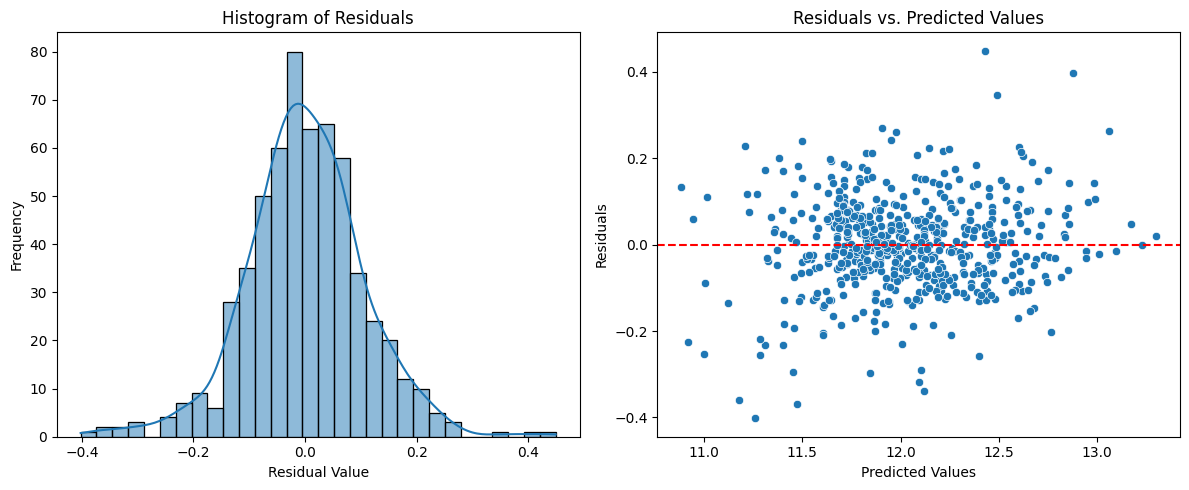

In [12]:
# Ridge Regression (Shrinks coefficients, drops nothing)
ridge_results = run_modeling_workflow(X, y, model_type='ridge', alpha=10.0)

## LASSO Regression (L1 Regularization)

*Optional: You can read about the history and mathematics of LASSO here: https://en.wikipedia.org/wiki/Lasso_(statistics)*

While Ridge regression is excellent at stabilizing models and handling multicollinearity, it has one distinct limitation: it never actually drops any features. If you start with 100 variables, Ridge will give you a model with 100 variables, it just shrinks their coefficients down to tiny numbers.

**LASSO** (Least Absolute Shrinkage and Selection Operator) serves as a mathematically elegant alternative that not only shrinks coefficients but performs automatic feature selection.

Like Ridge, Lasso fixes the overfitting tendencies of standard Ordinary Least Squares (OLS) by introducing a penalty for model complexity. However, they calculate their taxes differently:
* Ridge uses an L2 Penalty, taxing the squared value of the coefficients.
* Lasso uses an L1 Penalty, taxing the absolute value of the coefficients.

This slight change in the math leads to a massive difference in how the models behave. Because of the specific way the L1 penalty is calculated, Lasso doesn't just shrink weak or redundant coefficients asymptotically close to zero like Ridge does. Instead, it aggressively forces the coefficients of less useful variables to exactly 0.0. By zeroing out these coefficients, Lasso effectively drops the variables from the model entirely, leaving you with a simpler, highly interpretable final equation.

Just like Ridge, the strictness of this tax is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**; again, we will use alpha in this class):
* **If $\alpha = 0$:** There is no tax, and Lasso acts exactly like a standard, unregularized OLS regression.
* **As $\alpha$ increases:** The tax becomes stricter. While Ridge would just squash all the coefficients smaller, Lasso will progressively drop more and more predictors completely out of the model.

*Note: *If $\alpha$ is very high: The tax is so overwhelming that the model may drop all of the predictors, leaving you with nothing but the intercept.*

---

### Benefits of Lasso

* Automatic Feature Selection: Unlike Ridge regression (which shrinks coefficients but keeps them all), Lasso automatically removes features.
* Solves Multicollinearity: If you feed Lasso two variables that represent the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`), Lasso handles the multicollinearity for you. It will usually pick the slightly better predictor and drop the redundant one to zero.
* Reduces Overfitting: By simplifying the model and ignoring the "noise" in the training data, Lasso intentionally trades a tiny bit of accuracy on the training data (introducing bias) to achieve a massive improvement in predicting new, unseen data (reducing variance).

### Limitations of Lasso

* Mandatory Feature Scaling: I'll mention this again because this is the biggest trap for beginners. Because Lasso penalizes the size of the coefficients, it is entirely dependent on the scale of your data, just like Ridge. (For example, the coefficient for `Square Feet` will naturally be much smaller than the coefficient for `Number of Kitchens`). You must standardize or normalize all of your features before running Lasso, otherwise, the penalty will unfairly eliminate variables simply because they are measured in larger units.
* Arbitrary Selection Among Correlated Variables: While Lasso is great at handling multicollinearity, its method is somewhat arbitrary. If two features are highly correlated, Lasso will essentially pick one at random to keep and drop the other. This can be frustrating if it drops a variable that makes more logical sense for human interpretation.
* Loss of Traditional Interpretability (Biased Slopes): Just like Ridge (see above).
* Requires Hyperparameter Tuning: Just like Ridge (see above).

--- Running LASSO Cross-Validation on Training Data ---
--- Model Evaluation (LASSO) ---
Cross-validated R-squared: 0.8855 ± 0.0199
Cross-validated MSE:       0.0188 ± 0.0048

Intercept: 12.0180

Standardized Coefficients (using Lasso Regularization | alpha=0.01):
	MS SubClass          :	   -0.00  <-- Dropped
	Lot Frontage         :	    0.00
	Lot Area             :	    0.01
	Overall Qual         :	    0.13
	Overall Cond         :	    0.04
	Year Built           :	    0.07
	Year Remod/Add       :	    0.03
	BsmtFin SF 1         :	    0.03
	BsmtFin SF 2         :	    0.00  <-- Dropped
	Bsmt Unf SF          :	   -0.00  <-- Dropped
	Total Bsmt SF        :	    0.05
	1st Flr SF           :	    0.00
	2nd Flr SF           :	    0.00  <-- Dropped
	Gr Liv Area          :	    0.12
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.00  <-- Dropped
	Half Bath            :	    0.00  <-- Dropped
	Bedroom AbvGr        :	   -0.00  <-- Dropped
	TotRms AbvGrd        :	    0.00  <-- Dropped
	Fir

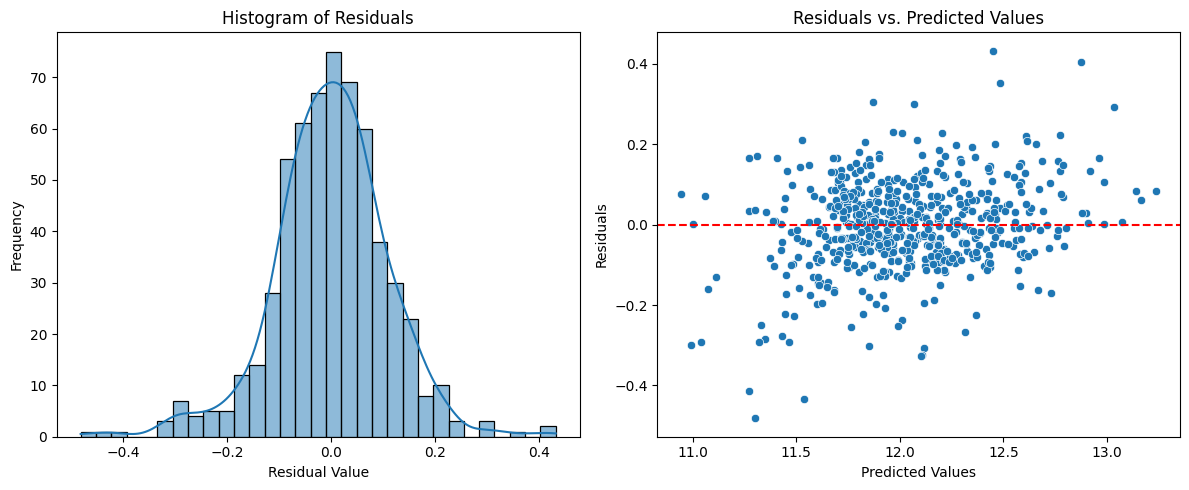

In [13]:
# Lasso Regression (Shrinks coefficients, drops redundant features to 0.0)
lasso_results = run_modeling_workflow(X, y, model_type='lasso', alpha=.01) # turn up alpha to increase the penalty and reduce features

### Elasticnet

ElasticNet combines both the L1 and L2 penalties.  

If you have two variables that measure almost the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`):
* **Lasso** will essentially flip a coin, keeping one variable and forcing the other to exactly zero. This is great for simplifying the model, but it loses information and can drop a variable you actually care about.
* **Ridge** will shrink both variables together smoothly, creating a highly stable model. But it will never force a coefficient to zero, meaning you are stuck with every single variable you started with.

ElasticNet Regression mathematically combines both Lasso and Ridge to get the best of both worlds.


*Historical Note:  Invented by Hui Zou and Trevor Hastie in 2005. After a decade of using Lasso, Zou and Hastie figure out a way to address Lasso's primary flaw; when faced with a group of highly correlated variables, Lasso would arbitrarily pick one and drop the rest. In fields like genetics, dropping correlated genes was problematic because all of them were part of the same biological pathway. Optional: read more about the history and mathematics here: https://en.wikipedia.org/wiki/Elastic_net_regularization*

#### Choosing Ratios
Instead of choosing between the L1 penalty (absolute value) or the L2 penalty (squared value), ElasticNet applies both taxes at the same time. Because it uses both penalties, it introduces a new concept: the **Mixing Parameter** (often called the `l1_ratio`). This allows you to slide a dial between Ridge and Lasso to find the perfect blend.
* An `l1_ratio` of 1.0 means it is 100% Lasso.
* An `l1_ratio` of 0.0 means it is 100% Ridge.
* An `l1_ratio` of 0.5 means the penalty is split 50/50 between the two methods.

---

#### Benefits of ElasticNet

* When it encounters a group of highly correlated variables, it doesn't arbitrarily kill all but one (like Lasso). Instead, it acts like Ridge: it keeps the whole group and shrinks their coefficients together. But, if a variable is completely useless, it acts like Lasso: it pushes that specific coefficient to exactly 0.0 and removes it.
* If you have a dataset where you have more columns (predictors) than you have rows (observations), standard regression and Lasso mathematically break down. ElasticNet handles this well, making it a favorite in fields like genetics where the number of features (like genes) often exceed the number of observations (people).
* Because you control the mix of L1 and L2, ElasticNet guarantees that your model will perform at least as well as Ridge or Lasso, because it can simply become one of them if that is what the data requires.

#### Limitations of ElasticNet

* **Double the Hyperparameter Tuning:** This is the biggest cost of ElasticNet. With Ridge or Lasso, you only had to test one parameter: the size of the penalty ($\alpha$). With ElasticNet, you have to test two parameters simultaneously: the size of the penalty ($\alpha$) AND the mix between L1/L2 (`l1_ratio`). This requires a 2D "Grid Search" during cross-validation, which takes significantly more computing time.
* **Mandatory Feature Scaling:** Just like Ridge and Lasso, ElasticNet applies a penalty based on the size of the coefficients. You must standardize or normalize your data before running it, or the math will unfairly penalize variables on larger numerical scales.
* **Biased Slopes:** Because the coefficients are shrunken to stabilize the model, they lose their literal, real-world interpretation. You cannot say "an extra square foot adds exactly $50" because the coefficient has been artificially compressed.
* **Still a Linear Model:** While ElasticNet is often the best possible linear model you can build, it still assumes relationships are straight lines. If your data involves complex thresholds or deep interactions, you will eventually need to graduate to non-linear machine learning approaches, which we will cover next .

---

#### Modern Usage, Accuracy versus Interpretability:

If they only care about predictive accuracy, researchers generally abandon linear models entirely at this stage and move on to tree-based models (like Random Forests or XGBoost).

However, if you do care about intepreting individual features, ElasticNet is currently the go-to method. It is popular in fields like bioinformatics, genomics, and econometrics where you have highly correlated features, or where you have more variables than rows of data (e.g., 10,000 genes but only 500 patients).

**Note on l1_ratio:** This parameter controls the mix of L1 and L2 penalties:
- l1_ratio = 0: Pure Ridge (L2 only)
- l1_ratio = 1: Pure Lasso (L1 only)
- l1_ratio = 0.5: Equal mix of both

We'll tune l1_ratio using cross-validation in Part 4.

--- Running ELASTICNET Cross-Validation on Training Data ---
--- Model Evaluation (ELASTICNET) ---
Cross-validated R-squared: 0.8890 ± 0.0190
Cross-validated MSE:       0.0182 ± 0.0046

Intercept: 12.0180

Standardized Coefficients (using Elasticnet Regularization | alpha=0.01, l1_ratio=0.5):
	MS SubClass          :	   -0.00  <-- Dropped
	Lot Frontage         :	    0.01
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.05
	Year Built           :	    0.07
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.03
	BsmtFin SF 2         :	    0.00  <-- Dropped
	Bsmt Unf SF          :	   -0.00  <-- Dropped
	Total Bsmt SF        :	    0.05
	1st Flr SF           :	    0.01
	2nd Flr SF           :	    0.00  <-- Dropped
	Gr Liv Area          :	    0.12
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.00  <-- Dropped
	Half Bath            :	    0.00  <-- Dropped
	Bedroom AbvGr        :	   -0.00  <-- Dropped
	TotRms AbvGrd       

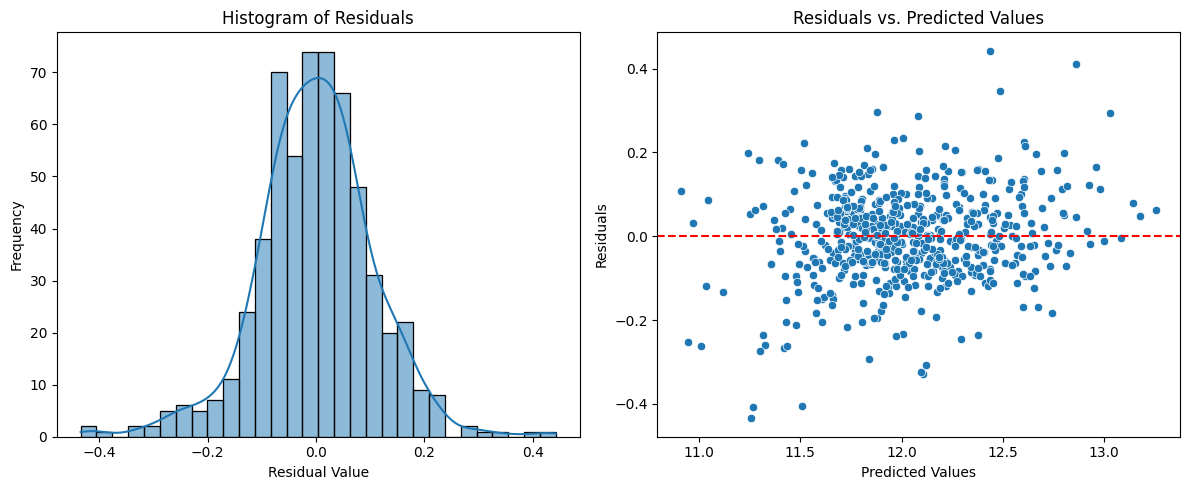

In [14]:
# 4. ElasticNet
enet_results = run_modeling_workflow(X, y, model_type='elasticnet', alpha=.01, l1_ratio=0.5)

## Model Comparison Summary

Let's compare all four approaches side-by-side:

In [15]:
# Create a comparison table
comparison_data = {
    'Model': ['OLS (Forward Selection)', 'Ridge (α=10.0)', 'Lasso (α=0.01)', 'ElasticNet (α=0.01, l1=0.5)'],
    'CV R² (mean ± std)': [
        f"{ols_results['cv_r2_mean']:.4f} ± {ols_results['cv_r2_std']:.4f}",
        f"{ridge_results['cv_r2_mean']:.4f} ± {ridge_results['cv_r2_std']:.4f}",
        f"{lasso_results['cv_r2_mean']:.4f} ± {lasso_results['cv_r2_std']:.4f}",
        f"{enet_results['cv_r2_mean']:.4f} ± {enet_results['cv_r2_std']:.4f}"
    ],
    'CV MSE (mean ± std)': [
        f"{ols_results['cv_mse_mean']:.4f} ± {ols_results['cv_mse_std']:.4f}",
        f"{ridge_results['cv_mse_mean']:.4f} ± {ridge_results['cv_mse_std']:.4f}",
        f"{lasso_results['cv_mse_mean']:.4f} ± {lasso_results['cv_mse_std']:.4f}",
        f"{enet_results['cv_mse_mean']:.4f} ± {enet_results['cv_mse_std']:.4f}"
    ],
    'Test R²': [
        f"{ols_results['final_r2']:.4f}",
        f"{ridge_results['final_r2']:.4f}",
        f"{lasso_results['final_r2']:.4f}",
        f"{enet_results['final_r2']:.4f}"
    ],
    'Features Kept': [
        len(ols_results['selected_features']),
        len(ridge_results['selected_features']),
        len(lasso_results['selected_features']),
        len(enet_results['selected_features'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                      Model CV R² (mean ± std) CV MSE (mean ± std) Test R²  Features Kept
    OLS (Forward Selection)    0.8895 ± 0.0172     0.0181 ± 0.0042  0.9337             19
             Ridge (α=10.0)    0.8902 ± 0.0178     0.0180 ± 0.0044  0.9358             38
             Lasso (α=0.01)    0.8855 ± 0.0199     0.0188 ± 0.0048  0.9304             22
ElasticNet (α=0.01, l1=0.5)    0.8890 ± 0.0190     0.0182 ± 0.0046  0.9334             24


Since these models run faster than basic forward and backward selection, let's try using them without removing most of the features. We can see more dramatic differences in how many features are retained.

Note: We use one hot enconding on categorical features with many values. This causes the number of features to explode (up to 276!)

In [16]:
# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'

# Loading the dataframe
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning: remove extreme outliers per the author's recommendation, large houses sold for little money due to inheritance
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()

# 1. Fix Garage Year Built in the Future
df.loc[df['Garage Yr Blt'] > 2010, 'Garage Yr Blt'] = 2010

# 2. Handle Numeric NaNs: Fill missing numbers with the column median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 3. Handle Categorical NaNs: Fill missing text with 'None'
# (In Ames, a NaN in 'PoolQC' or 'GarageType' just means the house doesn't have one)
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('None')

# 4. One-Hot Encoding: Convert all text categories into numeric columns (1s and 0s)
# Note: drop_first=True is CRITICAL for linear models to prevent multicollinearity!
df_clean = pd.get_dummies(df, drop_first=True)

# 5. Split into Features (X) and Target (y) ready for modeling
X = df_clean.drop('SalePrice', axis=1)
y = df_clean['SalePrice'].map(np.log)

print(f"Original shape: {df.shape} | Clean shape: {df_clean.shape}")

ridge_results = run_modeling_workflow(X, y, model_type='ridge',
                                      plot_residuals = False, alpha=10.0)
lasso_results = run_modeling_workflow(X, y, model_type='lasso',
                                      plot_residuals = False, alpha=.01)
enet_results = run_modeling_workflow(X, y, model_type='elasticnet',
                                     plot_residuals = False, alpha=.01, l1_ratio=0.8)

# Create a comparison table
comparison_data = {
    'Model': ['OLS (Forward Selection)', 'Ridge (α=10.0)', 'Lasso (α=0.01)', 'ElasticNet (α=0.01, l1=0.8)'],
    'CV R² (mean ± std)': [
        f"{ols_results['cv_r2_mean']:.4f} ± {ols_results['cv_r2_std']:.4f}",
        f"{ridge_results['cv_r2_mean']:.4f} ± {ridge_results['cv_r2_std']:.4f}",
        f"{lasso_results['cv_r2_mean']:.4f} ± {lasso_results['cv_r2_std']:.4f}",
        f"{enet_results['cv_r2_mean']:.4f} ± {enet_results['cv_r2_std']:.4f}"
    ],
    'CV MSE (mean ± std)': [
        f"{ols_results['cv_mse_mean']:.4f} ± {ols_results['cv_mse_std']:.4f}",
        f"{ridge_results['cv_mse_mean']:.4f} ± {ridge_results['cv_mse_std']:.4f}",
        f"{lasso_results['cv_mse_mean']:.4f} ± {lasso_results['cv_mse_std']:.4f}",
        f"{enet_results['cv_mse_mean']:.4f} ± {enet_results['cv_mse_std']:.4f}"
    ],
    'Test R²': [
        f"{ols_results['final_r2']:.4f}",
        f"{ridge_results['final_r2']:.4f}",
        f"{lasso_results['final_r2']:.4f}",
        f"{enet_results['final_r2']:.4f}"
    ],
    'Features Kept': [
        len(ols_results['selected_features']),
        len(ridge_results['selected_features']),
        len(lasso_results['selected_features']),
        len(enet_results['selected_features'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Original shape: (2925, 82) | Clean shape: (2925, 277)
--- Running RIDGE Cross-Validation on Training Data ---
--- Model Evaluation (RIDGE) ---
Cross-validated R-squared: 0.8992 ± 0.0216
Cross-validated MSE:       0.0166 ± 0.0049

Intercept: 12.0180

Standardized Coefficients (using Ridge Regularization | alpha=10.0):
	Order                 :	    0.00
	PID                   :	    0.02
	MS SubClass           :	   -0.01
	Lot Frontage          :	    0.01
	Lot Area              :	    0.02
	Overall Qual          :	    0.07
	Overall Cond          :	    0.05
	Year Built            :	    0.05
	Year Remod/Add        :	    0.01
	Mas Vnr Area          :	    0.00
	BsmtFin SF 1          :	    0.03
	BsmtFin SF 2          :	    0.01
	Bsmt Unf SF           :	    0.00
	Total Bsmt SF         :	    0.03
	1st Flr SF            :	    0.04
	2nd Flr SF            :	    0.04
	Low Qual Fin SF       :	    0.00
	Gr Liv Area           :	    0.07
	Bsmt Full Bath        :	    0.01
	Bsmt Half Bath        :	    0.00
	

Nearly identical results with these approaches when we throw in all of the features. Low 90's may be about as good as we reasonably expect in this dataset.